<a href="https://colab.research.google.com/github/danielmarin030513-ctrl/Ai-Project-TAM400-Daniel.M-Oskar.A/blob/main/Heart_Failure_Project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!pip install kagglehub

In [2]:
import kagglehub
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.linear_model import SGDClassifier
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    ConfusionMatrixDisplay,
    precision_score,
    recall_score,
    f1_score,
    roc_curve,
    roc_auc_score
)

In [3]:
path = kagglehub.dataset_download(
    "fedesoriano/heart-failure-prediction"
)

print("Path to dataset files:", path)

Using Colab cache for faster access to the 'heart-failure-prediction' dataset.
Path to dataset files: /kaggle/input/heart-failure-prediction


In [4]:
import os

os.listdir(path)

['heart.csv']

# **TEST**

In [5]:
df = pd.read_csv(f"{path}/heart.csv")

In [6]:
df.head()

,Age,Sex,ChestPainType,RestingBP,Cholesterol,FastingBS,RestingECG,MaxHR,ExerciseAngina,Oldpeak,ST_Slope,HeartDisease
0,40,M,ATA,140,289,0,Normal,172,N,0.0,Up,0
1,49,F,NAP,160,180,0,Normal,156,N,1.0,Flat,1
2,37,M,ATA,130,283,0,ST,98,N,0.0,Up,0
3,48,F,ASY,138,214,0,Normal,108,Y,1.5,Flat,1
4,54,M,NAP,150,195,0,Normal,122,N,0.0,Up,0


In [7]:
df.describe()

,Age,RestingBP,Cholesterol,FastingBS,MaxHR,Oldpeak,HeartDisease
count,918.000000,918.000000,918.000000,918.000000,918.000000,918.000000,918.000000
mean,53.510893,132.396514,198.799564,0.233115,136.809368,0.887364,0.553377
std,9.432617,18.514154,109.384145,0.423046,25.460334,1.066570,0.497414
min,28.000000,0.000000,0.000000,0.000000,60.000000,-2.600000,0.000000
25%,47.000000,120.000000,173.250000,0.000000,120.000000,0.000000,0.000000
50%,54.000000,130.000000,223.000000,0.000000,138.000000,0.600000,1.000000
75%,60.000000,140.000000,267.000000,0.000000,156.000000,1.500000,1.000000
max,77.000000,200.000000,603.000000,1.000000,202.000000,6.200000,1.000000


In [8]:
print(df.isnull().sum())

Age               0
Sex               0
ChestPainType     0
RestingBP         0
Cholesterol       0
FastingBS         0
RestingECG        0
MaxHR             0
ExerciseAngina    0
Oldpeak           0
ST_Slope          0
HeartDisease      0
dtype: int64


In [9]:
df['HeartDisease'].value_counts()

,count
HeartDisease,
1,508
0,410


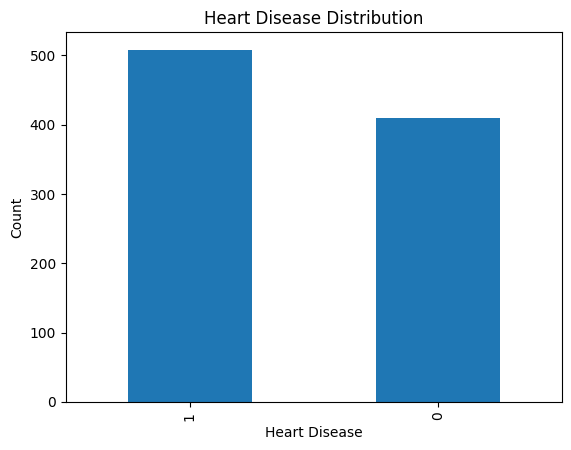

In [10]:
import matplotlib.pyplot as plt

df['HeartDisease'].value_counts().plot(kind='bar')

plt.title("Heart Disease Distribution")
plt.xlabel("Heart Disease")
plt.ylabel("Count")
plt.show()

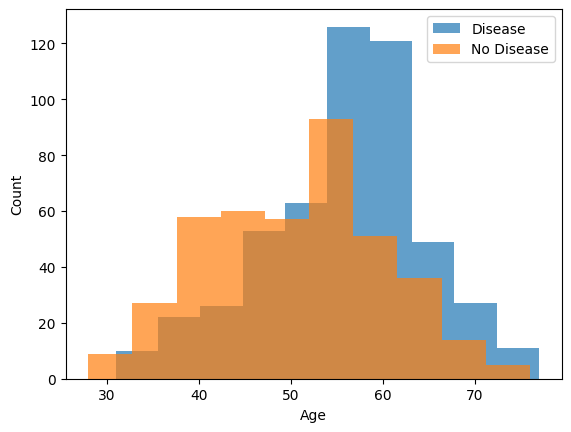

In [11]:
import matplotlib.pyplot as plt

plt.hist(df[df['HeartDisease'] == 1]['Age'], alpha=0.7, label='Disease')
plt.hist(df[df['HeartDisease'] == 0]['Age'], alpha=0.7, label='No Disease')

plt.xlabel('Age')
plt.ylabel('Count')
plt.legend()
plt.show()

In [12]:
X = df.drop('HeartDisease', axis=1)
y = df['HeartDisease']

X = pd.get_dummies(X, drop_first=True)

print(X.head())

   Age  RestingBP  Cholesterol  FastingBS  MaxHR  Oldpeak  Sex_M  \
0   40        140          289          0    172      0.0   True   
1   49        160          180          0    156      1.0  False   
2   37        130          283          0     98      0.0   True   
3   48        138          214          0    108      1.5  False   
4   54        150          195          0    122      0.0   True   

   ChestPainType_ATA  ChestPainType_NAP  ChestPainType_TA  RestingECG_Normal  \
0               True              False             False               True   
1              False               True             False               True   
2               True              False             False              False   
3              False              False             False               True   
4              False               True             False               True   

   RestingECG_ST  ExerciseAngina_Y  ST_Slope_Flat  ST_Slope_Up  
0          False             False          F

In [13]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print(X_train.shape)
print(X_test.shape)

(734, 15)
(184, 15)


In [14]:
model = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

model.fit(X_train, y_train)

RandomForestClassifier(random_state=42)

In [15]:
y_pred = model.predict(X_test)

In [17]:
print("Accuracy:", accuracy_score(y_test, y_pred))

print("Precision:", precision_score(y_test, y_pred))

print("Recall:", recall_score(y_test, y_pred))

print("F1-score:", f1_score(y_test, y_pred))

Accuracy: 0.875
Precision: 0.8962264150943396
Recall: 0.8878504672897196
F1-score: 0.892018779342723


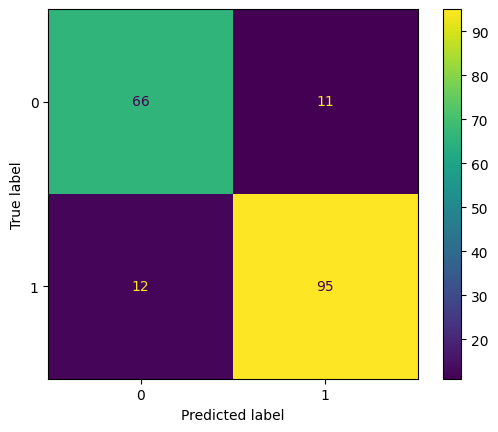

In [18]:
cm = confusion_matrix(y_test, y_pred)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm
)

disp.plot()

plt.show()

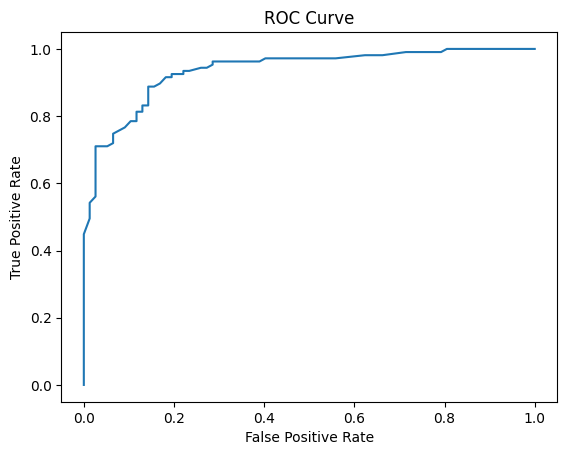

AUC: 0.936096613666707


In [19]:
y_prob = model.predict_proba(X_test)[:,1]

fpr, tpr, thresholds = roc_curve(
    y_test,
    y_prob
)

plt.plot(fpr, tpr)

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")

plt.show()

print("AUC:", roc_auc_score(y_test, y_prob))

In [20]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.85      0.86      0.85        77
           1       0.90      0.89      0.89       107

    accuracy                           0.88       184
   macro avg       0.87      0.87      0.87       184
weighted avg       0.88      0.88      0.88       184



In [21]:
import pandas as pd
import matplotlib.pyplot as plt

feature_importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": model.feature_importances_
})

feature_importance = feature_importance.sort_values(
    by="Importance",
    ascending=False
)

print(feature_importance)

              Feature  Importance
14        ST_Slope_Up    0.149099
4               MaxHR    0.117511
5             Oldpeak    0.112069
13      ST_Slope_Flat    0.108416
2         Cholesterol    0.103851
12   ExerciseAngina_Y    0.101613
0                 Age    0.088802
1           RestingBP    0.071584
6               Sex_M    0.036660
7   ChestPainType_ATA    0.033246
8   ChestPainType_NAP    0.023194
3           FastingBS    0.022405
10  RestingECG_Normal    0.015478
11      RestingECG_ST    0.009124
9    ChestPainType_TA    0.006949


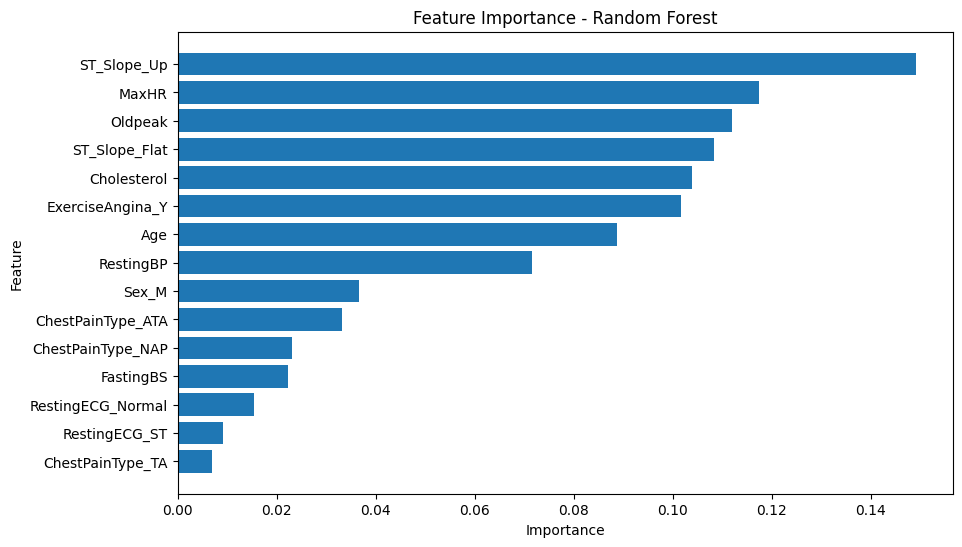

In [22]:
plt.figure(figsize=(10, 6))

plt.barh(
    feature_importance["Feature"],
    feature_importance["Importance"]
)

plt.xlabel("Importance")
plt.ylabel("Feature")
plt.title("Feature Importance - Random Forest")

plt.gca().invert_yaxis()
plt.show()

# KLAR